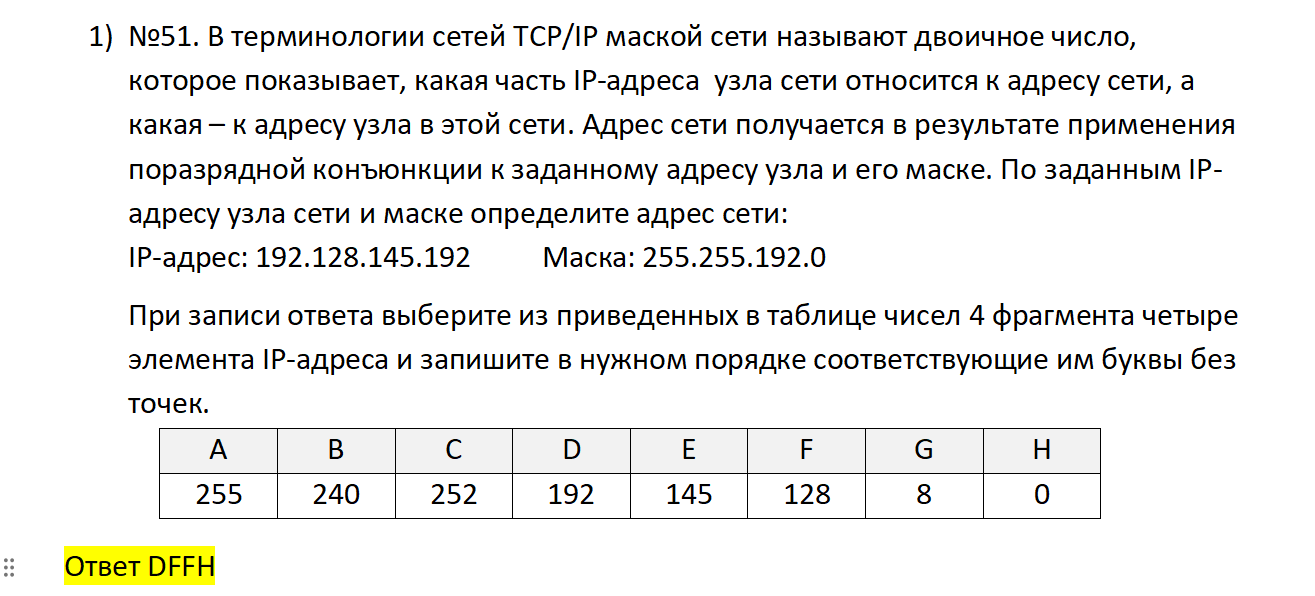

In [ ]:
ip = [192, 128, 145, 192]
mask = [255, 255, 192, 0]
res = []
for i in range(4):
    res.append(ip[i] & mask[i])
print(res)


3.  Если маска подсети 255.255.240.0 и IP-адрес компьютера в сети 162.198.75.44, то номер компьютера в сети равен 2860

In [8]:
ip = [162, 198, 75, 44]
mask = [255, 255, 240, 0]
res = []
for i in range(4):
    res.append(ip[i] & mask[i])
for i in range(4):
    print(bin(mask[i])[2:], end = ' ')
print('\n')
for i in range(4):
    l = len(bin(res[i])[2:])
    print('0' * (8-l)+bin(res[i])[2:], end = ' ')
host_number = (ip[2] - res[2]) * 256 + (ip[3] - res[3])
print('\n')
print(host_number)

11111111 11111111 11110000 0 

10100010 11000110 01000000 00000000 

2860


4. Если маска подсети 255.255.255.240 и IP-адрес компьютера в сети 162.198.0.44, то номер компьютера в сети равен 12

In [9]:
ip = [162, 198, 0, 44]
mask = [255, 255, 255, 240]
res = []
for i in range(4):
    res.append(ip[i] & mask[i])
for i in range(4):
    print(bin(mask[i])[2:], end = ' ')
print('\n')
for i in range(4):
    l = len(bin(res[i])[2:])
    print('0' * (8-l)+bin(res[i])[2:], end = ' ')
host_number = (ip[2] - res[2]) * 256 + (ip[3] - res[3])
print('\n')
print(host_number)

11111111 11111111 11111111 11110000 

10100010 11000110 00000000 00100000 

12


In [14]:
ip = [124, 128, 112, 142]
mask = []
res = [124, 128,64, 0]
print((8-len(bin(ip[2])[2:]))*'0'+bin(ip[2])[2:])
print((8-len(bin(res[2])[2:]))*'0'+bin(res[2])[2:])

print(int('11000000',2))


01110000
01000000
192


In [36]:
def t(s):
    a=s.split('.')
    return int(a[0])*2563+int(a[1])*2562+int(a[2])*256+int(a[3])

def ok(a,b,p):
    size=2**(32-p)
    if a//size==b//size: return False
    if a%size in (0,size-1): return False
    if b%size in (0,size-1): return False
    return True

a=t("192.168.106.35"); b=t("192.168.106.117")
L=[p for p in range(1,31) if ok(a,b,p)]
print(min(L), max(L))

a=t("156.77.32.127"); b=t("156.77.117.78")
L=[p for p in range(1,31) if ok(a,b,p)]
print(max(L))

23 29
29


### 3. №12467
В терминологии сетей TCP/IP маской сети называют двоичное число, которое показывает, какая часть IP-адреса узла сети относится к адресу сети, а какая – к адресу узла в этой сети. Адрес сети получается в результате применения поразрядной конъюнкции к заданному адресу узла и маске сети.

Адрес сети равен `183.192.A.0`, где **А** — некоторое допустимое для записи адреса сети число, а маска сети `255.255.252.0`.

Определите минимальное значение **А**, для которого для всех IP-адресов этой сети в двоичной записи IP-адреса суммарное количество единиц в правых двух байтах больше трёх.

**Ответ:** 60

---

### 4. №17867 (Демоверсия 2025)
Сеть задана IP-адресом `172.16.168.0` и маской сети `255.255.248.0`.

Сколько в этой сети IP-адресов, для которых количество единиц в двоичной записи IP-адреса не кратно 5?

**Ответ:** 1663

---

### 5. №14649
Сеть, в которой содержится узел с IP-адресом `116.242.A.26`, задана маской сети `255.255.255.224`, где **A** - некоторое допустимое для записи IP-адреса число.

Определите максимальное значение **A**, для которого для всех IP-адресов этой сети в двоичной записи IP-адреса суммарное количество единиц в левых двух байтах не меньше суммарного количества единиц в правых двух байтах.

**Ответ:** 240

---

### 6. №13885
Сеть, в которой содержится узел с IP-адресом `238.51.1.202`, задана маской сети `255.255.A.0`, где **A** - некоторое допустимое для записи маски число.

Определите минимальное значение **A**, для которого для всех IP-адресов этой сети в двоичной записи IP-адреса суммарное количество единиц в левых двух байтах не менее суммарного количества единиц в правых двух байтах.

**Ответ:** 252

In [18]:
def pc(x):
    return bin(x).count("1")

# 3
ans3=None
for A in range(0,256):
    if A%4!=0: continue
    ok=True
    for t in range(A,A+4):
        for d in range(256):
            if pc(t)+pc(d)<=3:
                ok=False
                break
        if not ok: break
    if ok:
        ans3=A
        break
print(ans3)

# 4
c=0
p=pc(172)+pc(16)
for t in range(168,176):
    for d in range(256):
        if (p+pc(t)+pc(d))%5!=0:
            c+=1
print(c)

# 5
L=pc(116)+pc(242)
ans5=None
for A in range(255,-1,-1):
    ok=True
    for d in range(32):
        if pc(A)+pc(d)>L:
            ok=False
            break
    if ok:
        ans5=A
        break
print(ans5)

# 6
L2=pc(238)+pc(51)
m=[0,128,192,224,240,248,252,254,255]
ans6=None
for A in m:
    b=1 & A
    ok=True
    for t in range(256):
        if (t & A)!=b: continue
        for d in range(256):
            if pc(t)+pc(d)>L2:
                ok=False
                break
        if not ok: break
    if ok:
        ans6=A
        break
print(ans6)

60
1663
240
252


1. **№138**
Два узла, находящиеся в разных подсетях, имеют IP-адреса `157.127.182.76` и `157.127.190.80`. В масках обеих подсетей одинаковое количество единиц. Укажите наименьшее возможное количество единиц в масках этих подсетей.

---

2. **№144**
Два узла, находящиеся в разных подсетях, имеют IP-адреса `118.187.59.255` и `118.187.65.115`. В масках обеих подсетей одинаковое количество единиц. Укажите наибольшее возможное количество единиц в масках этих подсетей. Учтите, что два адреса в любой подсети зарезервированы: адрес всей подсети и широковещательный адрес.

---

3. **№17676**
Сеть задана IP-адресом `115.192.0.0` и сетевой маской `255.192.0.0`.
Сколько в этой сети IP-адресов, для которых количество единиц в двоичной записи IP-адреса не кратно 3?

---

4. **№16324**
Сеть задана IP-адресом `122.159.136.144` и маской сети `255.255.255.248`.
Сколько в этой сети IP-адресов, для которых количество единиц в двоичной записи IP-адреса не кратно 4?

---

5. **№14648**
Для узла c IP-адресом `218.48.192.56` адрес сети равен `218.48.192.0`. Сколько существует различных возможных значений третьего слева байта маски, если известно, что в этой сети не менее 500 узлов? Ответ запишите в виде десятичного числа.

---

6. **№11791**
Сеть, в которой содержится узел с IP-адресом `246.51.128.202`, задана маской сети `255.255.A.0`, где `A` — некоторое допустимое для записи маски число. Определите минимальное значение `A`, для которого для всех IP-адресов этой сети в двоичной записи IP-адреса суммарное количество нулей в левых двух байтах не более суммарного количества нулей в правых двух байтах.

---

7. **№12467**
Адрес сети равен `183.192.A.0`, где `А` — некоторое допустимое для записи адреса сети число, а маска сети `255.255.252.0`.
Определите минимальное значение `А`, для которого для всех IP-адресов этой сети в двоичной записи IP-адреса суммарное количество единиц в правых двух байтах больше трёх.

---

8. **№11835**
Сеть, в которой содержится узел с IP-адресом `207.0.A.167`, задана маской сети `255.255.255.192`, где `A` — некоторое допустимое для записи IP-адреса число. Определите количество значений `A`, для которых для всех IP-адресов этой сети в двоичной записи IP-адреса суммарное количество нулей в левых двух байтах больше суммарного количества нулей в правых двух байтах.

In [19]:
def pc(x):
    return bin(x).count("1")

def to_ints(ip):
    return list(map(int, ip.split(".")))

def mks(m):
    a=[0,0,0,0]
    f=m//8
    r=m%8
    for i in range(f):
        a[i]=255
    if r>0:
        a[f]=256-2**(8-r)
    return a

def net(ip,m):
    i=to_ints(ip)
    k=mks(m)
    return [i[j]&k[j] for j in range(4)]

def okmask(ip1,ip2):
    r=[]
    for m in range(32,0,-1):
        if net(ip1,m)!=net(ip2,m):
            if 2**(32-m)>=4:
                r.append(m)
    return r

# 1 №138 минимальное
x=okmask("157.127.182.76","157.127.190.80")
print(x[-1])

# 2 №144 максимальное
y=okmask("118.187.59.255","118.187.65.115")
print(y[0])

# 3 №17676
p=bin(115).count("1")+bin(192).count("1")
C=[1]
for i in range(1,23):
    C.append(C[-1]*(22-i+1)//i)
s3=0
for k in range(23):
    if (p+k)%3!=0:
        s3+=C[k]
print(s3)

# 4 №16324
b=[122,159,136,144]
s4=0
for d in range(8):
    if sum(pc(b[i]+(d if i==3 else 0)) for i in range(4))%4!=0:
        s4+=1
print(s4)

# 5 №14648
v=[0,128,192,224,240,248,252,254,255]
c5=0
for m in v:
    if (192&m)==192:
        o=bin(m).count("1")
        h=32-(16+o)
        if 2**h-2>=500:
            c5+=1
print(c5)

# 6 №11791
L=(8-pc(246))+(8-pc(51))
v=[0,128,192,224,240,248,252,254,255]
ans6=None
for A in v:
    b=(128&A)
    ok=True
    for t in range(256):
        if (t&A)==b:
            for d in range(256):
                if L>(8-pc(t)+8-pc(d)):
                    ok=False
                    break
        if not ok: break
    if ok:
        ans6=A
        break
print(ans6)

# 7 №12467 повтор
ans7=None
for A in range(256):
    if A%4==0:
        ok=True
        for t in range(A,A+4):
            for d in range(256):
                if pc(t)+pc(d)<=3:
                    ok=False
                    break
            if not ok: break
        if ok:
            ans7=A
            break
print(ans7)

# 8 №11835
L2=(8-pc(207))+(8-pc(0))
c8=0
for A in range(256):
    base=167&192
    ok=True
    for d in range(base,base+64):
        if not (L2>(8-pc(A)+8-pc(d))):
            ok=False
            break
    if ok:
        c8+=1
print(c8)

21
30
2796202
5
6
254
60
37
